# 05.2 – Modeling Attrition Prediction with Random Forest

## 🎯 Mục tiêu

Notebook này thực hiện **huấn luyện mô hình Random Forest** cho bài toán **dự đoán nghỉ việc (Attrition)**, với trọng tâm là **phát hiện đúng nhân viên có khả năng nghỉ việc (Leave)** trong bối cảnh **dữ liệu mất cân bằng nghiêm trọng**.

Khác với các bài toán phân lớp thông thường, trong bài toán này việc **dự đoán chính xác lớp thiểu số (Leave)** quan trọng hơn so với việc tối ưu độ chính xác tổng thể (Accuracy).

### Các mục tiêu cụ thể

- Xây dựng mô hình **Random Forest** cho bài toán phân lớp nhị phân (**Leave / Stay**)
- Áp dụng kỹ thuật **xử lý mất cân bằng dữ liệu** thông qua tham số `class_weight`
- **Tối ưu threshold dự đoán** nhằm cải thiện khả năng phát hiện nhân viên sẽ nghỉ việc (**Recall của lớp Leave**)
- Đánh giá mô hình bằng các chỉ số phù hợp với lớp thiểu số, bao gồm:
  - **Recall (Leave)**
  - **Precision (Leave)**
  - **F1-score**
  - **PR-AUC**
  - **Recall@TopK**
- Lưu **model, scaler, metrics và kết quả dự đoán** để phục vụ so sánh và đánh giá tổng hợp ở notebook **Evaluation**

In [20]:
# ================================
# Import toàn bộ thư viện cần thiết
# ================================

# Thư viện hệ thống
import os
import time
import json
import joblib

# Xử lý dữ liệu
import numpy as np
import pandas as pd

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score
)

In [21]:
# ================================
# Cấu hình chung cho notebook
# ================================

# Cấu hình hiển thị biểu đồ
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Seed để tái lập kết quả
RANDOM_STATE = 42

# Các tham số phục vụ cải thiện phát hiện Leave
THRESHOLD_RANGE = np.arange(0.1, 0.6, 0.05)  # dùng để tối ưu threshold
TOP_K_RATIO = 0.2                            # dùng cho Recall@TopK

In [22]:
# ================================
# Đọc dữ liệu đã tiền xử lý
# ================================

DATA_PATH = "../data/processed/hr_processed_ml.csv"

# Đọc dữ liệu
df = pd.read_csv(DATA_PATH)

# Kiểm tra nhanh dữ liệu
print("Shape:", df.shape)
df.head()

Shape: (1480, 53)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,SalarySlab_15k+,SalarySlab_5k-10k,SalarySlab_Upto 5k,OverTime_Yes,Attrition
0,-2.07305,-1.417860,-0.765246,0.087146,0.252402,-0.582896,0.379185,-0.963504,0.249148,-1.082217,...,False,False,False,False,True,False,False,True,False,1
1,-2.07305,0.026342,0.095926,0.087146,1.167977,0.155242,-1.023800,-0.963504,0.249148,-1.129039,...,False,False,True,False,True,False,False,True,False,0
2,-2.07305,1.252176,-0.519197,0.087146,-0.663173,0.155242,0.379185,-0.963504,-0.656844,-0.984743,...,False,False,True,False,True,False,False,True,True,1
3,-2.07305,-1.276417,-0.519197,-0.889941,-0.663173,0.352079,0.379185,-0.963504,1.155139,-1.160750,...,True,False,False,False,True,False,False,True,False,0
4,-2.07305,-1.375675,-0.150123,-1.867028,0.252402,0.696543,0.379185,-0.963504,0.249148,-0.979210,...,False,False,False,False,True,False,False,True,False,1


In [23]:
# ================================
# Cấu hình thư mục lưu kết quả
# ================================

BASE_MODEL_DIR = "../data/processed/models/rf"
os.makedirs(BASE_MODEL_DIR, exist_ok=True)

MODEL_PATH   = os.path.join(BASE_MODEL_DIR, "rf_model.pkl")
SCALER_PATH  = os.path.join(BASE_MODEL_DIR, "rf_scaler.pkl")
METRICS_PATH = os.path.join(BASE_MODEL_DIR, "rf_metrics.json")
PRED_PATH    = os.path.join(BASE_MODEL_DIR, "rf_predictions.csv")

print("Artifacts will be saved to:", BASE_MODEL_DIR)

Artifacts will be saved to: ../data/processed/models/rf


In [24]:
# ================================
# Xác định biến mục tiêu và tập đặc trưng
# ================================

TARGET_COL = "Attrition"

# Tách biến đầu vào và nhãn
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Kiểm tra phân bố nhãn (rất quan trọng với bài toán mất cân bằng)
print("X shape:", X.shape)
print("Phân bố nhãn y:")
print(y.value_counts(normalize=True))

X shape: (1480, 52)
Phân bố nhãn y:
Attrition
0    0.839189
1    0.160811
Name: proportion, dtype: float64


In [25]:
# ================================
# Chia dữ liệu train / test
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # giữ nguyên tỷ lệ nhãn
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (1184, 52)
Test size : (296, 52)


In [26]:
# ================================
# Chuẩn hoá dữ liệu
# ================================

# Random Forest không yêu cầu chuẩn hoá,
# nhưng vẫn dùng scaler để đồng bộ pipeline giữa các mô hình
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [27]:
# ================================
# Khởi tạo mô hình Random Forest
# ================================

rf_model = RandomForestClassifier(
    n_estimators=400,            # số lượng cây
    max_depth=12,                # giới hạn độ sâu để tránh overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",     # ⚠️ xử lý mất cân bằng nhãn
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [28]:
# ================================
# Huấn luyện mô hình
# ================================

start_time = time.time()

rf_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

Training time: 0.61 seconds


In [29]:
# ================================
# Dự đoán xác suất lớp Leave
# ================================

# Lấy xác suất dự đoán cho lớp Leave (label = 1)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# ================================
# Tối ưu threshold theo F1-score Leave
# ================================

best_threshold = 0.5
best_f1 = 0

for t in THRESHOLD_RANGE:
    y_tmp = (y_proba >= t).astype(int)
    f1_tmp = f1_score(y_test, y_tmp)

    if f1_tmp > best_f1:
        best_f1 = f1_tmp
        best_threshold = t

print("Best threshold (by F1):", best_threshold)
print("Best F1-score:", round(best_f1, 4))

Best threshold (by F1): 0.30000000000000004
Best F1-score: 0.5248


In [31]:
# ================================
# Chuyển sang nhãn nhị phân với threshold tối ưu
# ================================

y_pred = (y_proba >= best_threshold).astype(int)

In [32]:
# ================================
# Đánh giá mô hình (Leave-focused)
# ================================

pr_auc = average_precision_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
recall_leave = recall_score(y_test, y_pred)
precision_leave = precision_score(y_test, y_pred)

print("PR-AUC :", round(pr_auc, 4))
print("F1-score:", round(f1, 4))
print("Recall (Leave):", round(recall_leave, 4))
print("Precision (Leave):", round(precision_leave, 4))

PR-AUC : 0.5566
F1-score: 0.5248
Recall (Leave): 0.7708
Precision (Leave): 0.3978


In [33]:
# ================================
# Recall@TopK
# ================================

top_k = int(len(y_test) * TOP_K_RATIO)
top_k_idx = np.argsort(y_proba)[-top_k:]

recall_at_k = y_test.iloc[top_k_idx].sum() / y_test.sum()
print(f"Recall@Top {int(TOP_K_RATIO*100)}%:", round(recall_at_k, 4))

Recall@Top 20%: 0.5625


In [34]:
# ================================
# Báo cáo phân lớp chi tiết
# ================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Stay", "Leave"]
    )
)

              precision    recall  f1-score   support

        Stay       0.95      0.77      0.85       248
       Leave       0.40      0.77      0.52        48

    accuracy                           0.77       296
   macro avg       0.67      0.77      0.69       296
weighted avg       0.86      0.77      0.80       296



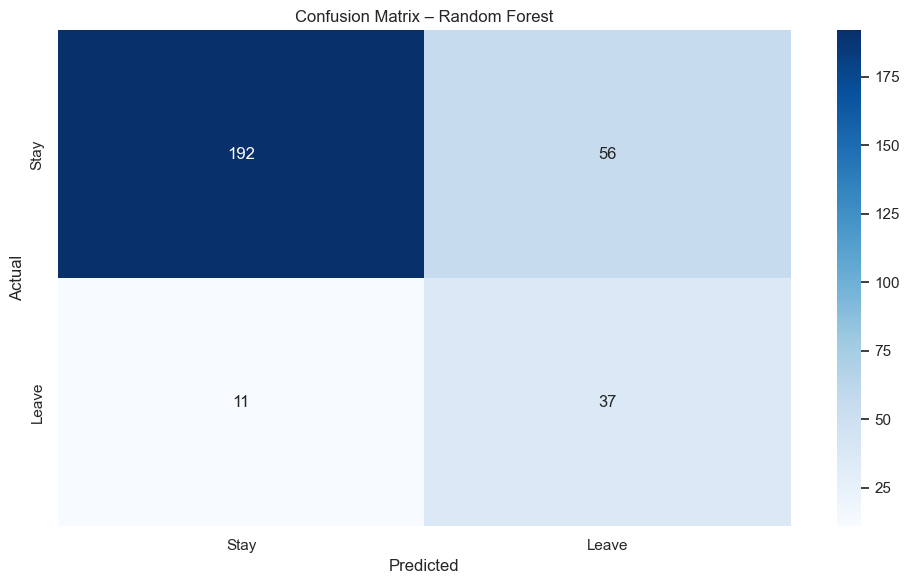

In [35]:
# ================================
# Confusion Matrix
# ================================

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Leave"],
    yticklabels=["Stay", "Leave"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.tight_layout()
plt.show()

In [36]:
# ================================
# Lưu kết quả dự đoán
# ================================

pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_proba,
    "y_pred": y_pred
})

pred_df.to_csv(PRED_PATH, index=False)
print("Saved predictions to:", PRED_PATH)

Saved predictions to: ../data/processed/models/rf\rf_predictions.csv


In [37]:
# ================================
# Lưu metrics và hyperparameters
# ================================

metrics = {
    "model": "RandomForest",
    "pr_auc": float(pr_auc),
    "f1_score": float(f1),
    "recall_leave": float(recall_leave),
    "precision_leave": float(precision_leave),
    "best_threshold": float(best_threshold),
    "train_time_sec": float(train_time),
    "n_estimators": 400,
    "max_depth": 12,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics to:", METRICS_PATH)

Saved metrics to: ../data/processed/models/rf\rf_metrics.json


In [38]:
# ================================
# Lưu model và scaler
# ================================

joblib.dump(rf_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("Saved model  to:", MODEL_PATH)
print("Saved scaler to:", SCALER_PATH)

Saved model  to: ../data/processed/models/rf\rf_model.pkl
Saved scaler to: ../data/processed/models/rf\rf_scaler.pkl
